In [128]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

In [118]:
DIR = Path("../../artifacts/2023-07-s9/experiments/basis-accuracy-seeds")

In [174]:
def load(dataset, logit_mod, arch, layer, basis_name, basis_mode, seeds=list(range(1, 5+1))):
    
    arr_dfs = []
    for seed in seeds:
        with open(DIR / f"{dataset}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"]
            }
        )
        df["dims"] = data["dims"]

        # remark: the attribute name here is misnormzer. 
        # perhaps, we refactor it.
        df["original_acc"] = data["original_auroc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"][0]).all()
    
    for col in ["original_acc", "dims"]:
        
        assert (df[col]["first"] == df[col]["first"][0]).all()

    return df

load(
    "cifar100-people--n500", 
    "oneclass", 
    "cifar100-resnet18-p1",
    "layer3", 
    "pca", 
    basis_mode="centered",
)

acc            seed original_acc  dims
       mean       std count        first first
k                                             
0    0.2000  0.000000     5         0.55   256
1    0.1816  0.003286     5         0.55   256
2    0.2108  0.001095     5         0.55   256
3    0.2384  0.003286     5         0.55   256
4    0.2248  0.003033     5         0.55   256
..      ...       ...   ...          ...   ...
240  0.5496  0.003286     5         0.55   256
244  0.5488  0.001095     5         0.55   256
248  0.5532  0.001095     5         0.55   256
252  0.5504  0.000894     5         0.55   256
256  0.5500  0.000000     5         0.55   256

[68 rows x 5 columns]

In [172]:
df.index

Index([  0,   1,   2,   3,   4,   8,  12,  16,  20,  24,  28,  32,  36,  40,
        44,  48,  52,  56,  60,  64,  68,  72,  76,  80,  84,  88,  92,  96,
       100, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152,
       156, 160, 164, 168, 172, 176, 180, 184, 188, 192, 196, 200, 204, 208,
       212, 216, 220, 224, 228, 232, 236, 240, 244, 248, 252, 256],
      dtype='int64', name='k')

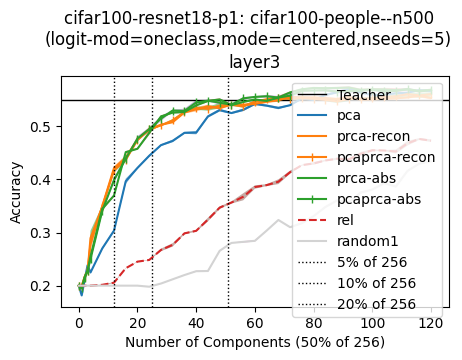

In [204]:
import numpy as np 

def color(name):
    if "random" in name:
        return "lightgray"
    else:
        return None

def marker(name):
    if "pcaprca" in name:
        return "|"
    
def ls(name):
    if "rel" in name:
        return "--"
    else:
        return "-"
def viz(
    dataset, logit_mod, 
    percent=0.2, num_samples=500, basis_mode="centered", 
    layers=["layer3", "layer4"],
    basis_names=[
        "pca",
        "prca-recon",
        "prca-abs", 
        "rel", 
        "random1", 
    ]
):
    dataset =  f"{dataset}--n{num_samples}"
    arch = "cifar100-resnet18-p1"

    ncols = len(layers)
    plt.figure(figsize=(ncols * 5, 3))
    
#     nn = None
    for lix, layer in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        plt.ylabel("Accuracy")
        for bix, basis_name in enumerate(basis_names):
            df = load(dataset, logit_mod, arch, layer, basis_name, basis_mode)
            d = df["dims"]["first"].values[-1]
            k = df.index

            nseeds =df["seed"]["count"].values[-1]
            nn = np.argwhere(np.array(k) < percent * d).reshape(-1)[-1]

            if bix == 0:
                teacher_metric = df["original_acc"]["first"].values[-1]

                plt.axhline(teacher_metric, ls='-', lw=1, color="k", label="Teacher")
            
            
            vcolor = color(basis_name)
            
            if "pcaprca" in basis_name:
                vcolor = plt.gca().lines[-1].get_color()
            
            stderr = df["acc"]["std"][:nn] / (nseeds ** 0.5)
            mean = df["acc"]["mean"][:nn] 
            plt.plot(
                k[:nn],
                mean,
                label=basis_name,
                color=vcolor,
                ls=ls(basis_name),
                marker=marker(basis_name)
            )
            
            plt.fill_between(
                k[:nn],
                mean - stderr,
                mean + stderr,
                alpha=0.5
            )
            
        for p in [0.05, 0.1, 0.2]:
            
            plt.axvline(int(p*d), ls=":", lw=1, color="k", label=f"{int(p*100)}% of {d}")
        plt.xlabel(f"Number of Components ({int(percent*100):d}% of {d})")

        if lix == len(layers) - 1:
            plt.legend()
            
    plt.suptitle(f"{arch}: {dataset}\n(logit-mod={logit_mod},mode={basis_mode},nseeds={nseeds})", y=1.1)

viz(
    "cifar100-people",
    "oneclass",
    basis_mode="centered",
    layers=["layer3", "layer4"][:1],
    percent=0.5,
    basis_names=[
        "pca",
        "prca-recon",
        "pcaprca-recon",
        "prca-abs", 
        'pcaprca-abs',
        "rel", 
        "random1", 
    ]
)

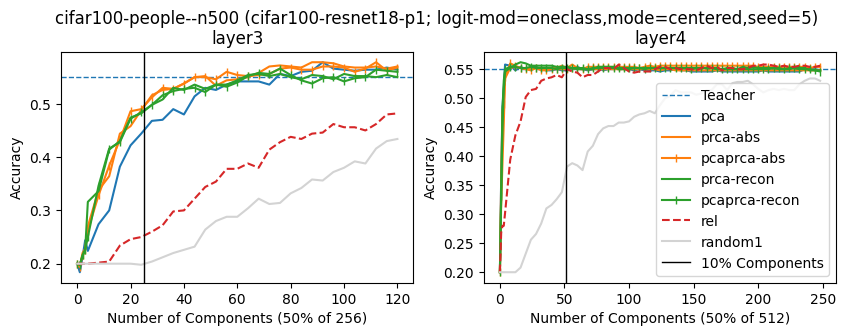

In [127]:
viz(
    "cifar100-people",
    "oneclass",
    basis_mode="centered",
    layers=["layer3", "layer4"],
    seed=5,
    percent=0.5
)



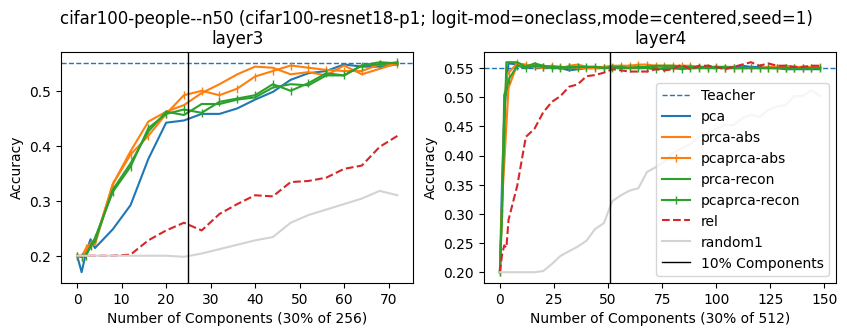

In [107]:
viz(
    "cifar100-people",
    "oneclass",
    basis_mode="centered",
    layers=["layer3", "layer4"],
    seed=1,
    num_samples=50,
    percent=0.3

)

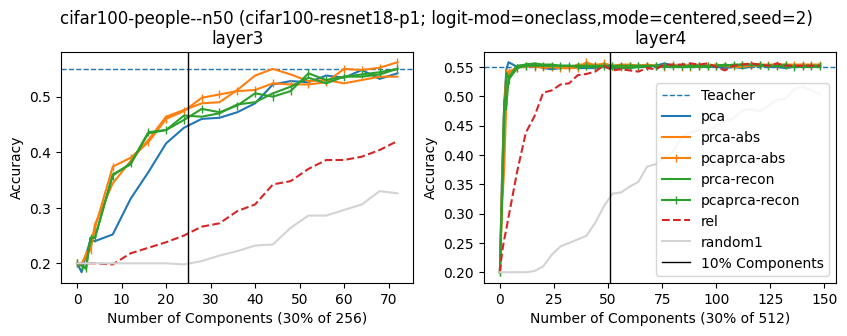

In [109]:
viz(
    "cifar100-people",
    "oneclass",
    basis_mode="centered",
    layers=["layer3", "layer4"],
    seed=2,
    num_samples=50,
    percent=0.3
)

## next step: 
DIR: `./artifacts/2023-07-s9/experiments/basis-accuracy-seeds`

- n=500, 299258_*
- n=250, 299263
- n=50, 299268

TODO:
Rewrite the plot and aggregate over seeds